# 🔮 Modelagem v2 — Previsão Real (Forecasting) de Alagamentos em SP
## TCC · Henrique Nascimento Santos

**Correção metodológica fundamental:** a v1 deste notebook media a relação entre clima do
dia *t* e alagamento do **mesmo dia** *t* — isto é **nowcasting** (diagnóstico do presente),
não previsão. Esta versão reformula o problema como **forecasting genuíno**: dado tudo que
sabemos até o dia *t*, qual a chance de alagar em *t+1*, *t+2* ou *t+3*?

**Mudança central:**
```
ANTES (nowcasting):  X[t]   →  y[t]      "Choveu hoje, alagou hoje?"
AGORA (forecasting): X[≤t]  →  y[t+h]    "Com o que sei até hoje, vai alagar em h dias?"
```

Espera-se que as métricas **caiam** em relação à v1 — isso é o resultado correto e esperado,
não um erro. Alagamento urbano é majoritariamente resposta rápida à chuva (minutos a horas),
então prever com 24–72h de antecedência é estruturalmente mais difícil, e quantificar essa
queda é, em si, um resultado relevante para o TCC.


## 0. Setup

In [13]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, f1_score, recall_score, precision_score,
    ConfusionMatrixDisplay
)

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9", "axes.grid": True,
    "grid.alpha": 0.35, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, RED, GREEN, ORANGE, PURPLE = "#378ADD", "#E05252", "#1D9E75", "#EF9F27", "#8B5CF6"

print("✓ Setup concluído.")


✓ Setup concluído.


In [14]:
# ── Carregamento ───────────────────────────────────────────────────────────
BASE = "../../data/outputs/datasets"

# Usar o dataset final integrado (CEMADEN + ERA5 + target) já consolidado
df = pd.read_csv(f"{BASE}/dataset_final_integrado.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Garantir colunas temporais
df["month"]     = df["date"].dt.month
df["is_summer"] = df["month"].isin([11,12,1,2,3]).astype(int)

print(f"✓ Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"  Período: {df['date'].min().date()} → {df['date'].max().date()}")


✓ Dataset carregado: 4,169 linhas × 21 colunas
  Período: 2015-01-01 → 2026-05-31


## 1. Diagnóstico — Por que a v1 era Nowcasting, não Previsão

In [15]:
# Demonstração: todas as features de precipitação "acc" e "lag" são calculadas
# com rolling/shift sobre o PRÓPRIO dia t — então acc3d[t] = precip[t]+precip[t-1]+precip[t-2].
# Isso é válido como feature para prever t+1, mas não deveria coexistir com
# precipitation_sum[t] (chuva do PRÓPRIO dia) quando o target também é do dia t.

example = df[["date","precipitation_sum","precipitation_sum_acc3d" if "precipitation_sum_acc3d" in df.columns else "cemaden_precip_acc3d"]].head(6)
print("Exemplo: acumulado de 3 dias inclui o próprio dia t")
print(example.to_string())
print()
print("→ Na v1, X[t] incluía precipitation_sum[t] (chuva DESTE dia) para prever has_flooding[t]")
print("  (alagamento DESTE MESMO dia). Isso é quase tautológico: alagamento urbano em SP")
print("  ocorre minutos a horas após a chuva, no mesmo dia.")
print()
print("→ Nesta v2, mantemos as mesmas features X[t] (todas calculadas até o dia t,")
print("  sem olhar o futuro), mas deslocamos o TARGET para t+1, t+2, t+3.")


Exemplo: acumulado de 3 dias inclui o próprio dia t
        date  precipitation_sum  precipitation_sum_acc3d
0 2015-01-01                0.3                      NaN
1 2015-01-02                7.8                      NaN
2 2015-01-03                5.7                     13.8
3 2015-01-04               20.9                     34.4
4 2015-01-05                5.9                     32.5
5 2015-01-06               10.3                     37.1

→ Na v1, X[t] incluía precipitation_sum[t] (chuva DESTE dia) para prever has_flooding[t]
  (alagamento DESTE MESMO dia). Isso é quase tautológico: alagamento urbano em SP
  ocorre minutos a horas após a chuva, no mesmo dia.

→ Nesta v2, mantemos as mesmas features X[t] (todas calculadas até o dia t,
  sem olhar o futuro), mas deslocamos o TARGET para t+1, t+2, t+3.


## 2. Construção dos Targets de Previsão (h = 1, 2, 3 dias)

Criamos três targets, cada um representando um horizonte de previsão:

```
has_flooding_h1[t] = has_flooding[t+1]   →  alaga em 1 dia?
has_flooding_h2[t] = has_flooding[t+2]   →  alaga em 2 dias?
has_flooding_h3[t] = has_flooding[t+3]   →  alaga em 3 dias?
```

Todas as features permanecem ancoradas no dia *t* (presente) — nenhuma informação do
futuro é usada para prever o futuro.


In [16]:
HORIZONS = [1, 2, 3]

for h in HORIZONS:
    df[f"target_h{h}"] = df["has_flooding"].shift(-h)

# Visualizar a construção
print("Exemplo de construção dos targets (10 primeiras linhas):")
cols_show = ["date", "has_flooding", "target_h1", "target_h2", "target_h3"]
print(df[cols_show].head(10).to_string(index=False))
print()
print("Note: target_h1[t] == has_flooding[t+1]  (deslocamento correto)")
print()

# Os últimos `h` dias de cada target ficam NaN (não há futuro para olhar)
for h in HORIZONS:
    n_nan = df[f"target_h{h}"].isna().sum()
    print(f"  target_h{h}: {n_nan} dias finais sem valor (esperado: {h})")


Exemplo de construção dos targets (10 primeiras linhas):
      date  has_flooding  target_h1  target_h2  target_h3
2015-01-01             1        1.0        1.0        0.0
2015-01-02             1        1.0        0.0        1.0
2015-01-03             1        0.0        1.0        1.0
2015-01-04             0        1.0        1.0        1.0
2015-01-05             1        1.0        1.0        1.0
2015-01-06             1        1.0        1.0        0.0
2015-01-07             1        1.0        0.0        1.0
2015-01-08             1        0.0        1.0        1.0
2015-01-09             0        1.0        1.0        1.0
2015-01-10             1        1.0        1.0        0.0

Note: target_h1[t] == has_flooding[t+1]  (deslocamento correto)

  target_h1: 1 dias finais sem valor (esperado: 1)
  target_h2: 2 dias finais sem valor (esperado: 2)
  target_h3: 3 dias finais sem valor (esperado: 3)


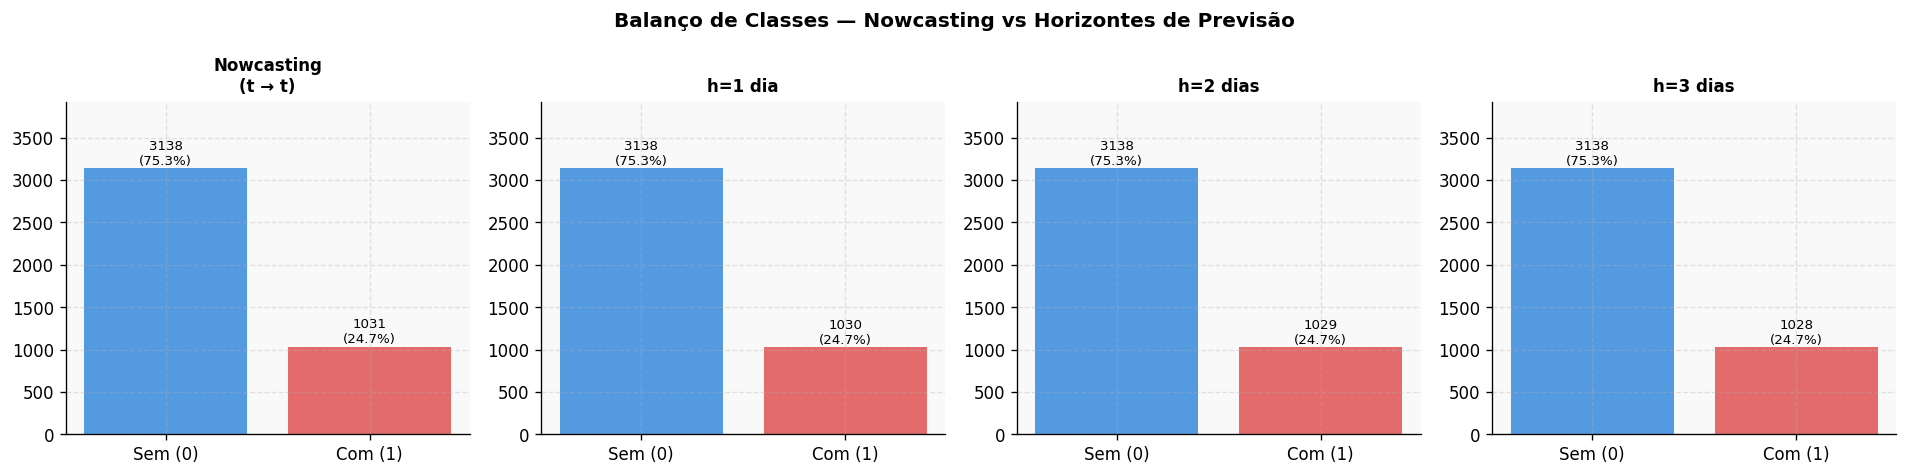

In [17]:
# Balanço de classes por horizonte — deve ser muito similar ao nowcasting original
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (label, col) in zip(axes, [("Nowcasting\n(t → t)", "has_flooding"),
                                    ("h=1 dia", "target_h1"),
                                    ("h=2 dias", "target_h2"),
                                    ("h=3 dias", "target_h3")]):
    vals = df[col].dropna()
    counts = vals.value_counts().sort_index()
    colors = [BLUE, RED]
    bars = ax.bar(["Sem (0)","Com (1)"], counts.values, color=colors, alpha=0.85)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+10, f"{v}\n({v/len(vals)*100:.1f}%)",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(label, fontweight="bold", fontsize=10)
    ax.set_ylim(0, counts.max()*1.25)

plt.suptitle("Balanço de Classes — Nowcasting vs Horizontes de Previsão", fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Features — Garantindo Ausência de Leakage Temporal

Regra: **toda feature usada deve ser computável com informação disponível até o dia *t*,
inclusive**. Isso vale tanto para nowcasting quanto para forecasting — a diferença está
apenas em qual dia o *target* representa.


In [18]:
CEMADEN_FEATURES = [c for c in [
    "cemaden_precip_idw_mm", "cemaden_precip_median_mm", "cemaden_precip_max_mm",
    "cemaden_intensity_max_hor", "cemaden_precip_lag1d", "cemaden_precip_lag2d",
    "cemaden_precip_lag3d", "cemaden_precip_acc3d", "cemaden_precip_acc7d",
    "cemaden_precip_acc14d",
] if c in df.columns]

ERA5_FEATURES = [c for c in [
    "precipitation_sum", "precipitation_sum_acc3d", "precipitation_sum_acc7d",
    "soil_moisture_0_to_7cm_mean",
] if c in df.columns]

TEMPORAL_FEATURES = ["month", "is_summer"]

ALL_FEATURES = CEMADEN_FEATURES + ERA5_FEATURES + TEMPORAL_FEATURES
print(f"Features disponíveis: {len(ALL_FEATURES)}")
print(ALL_FEATURES)


Features disponíveis: 16
['cemaden_precip_idw_mm', 'cemaden_precip_median_mm', 'cemaden_precip_max_mm', 'cemaden_intensity_max_hor', 'cemaden_precip_lag1d', 'cemaden_precip_lag2d', 'cemaden_precip_lag3d', 'cemaden_precip_acc3d', 'cemaden_precip_acc7d', 'cemaden_precip_acc14d', 'precipitation_sum', 'precipitation_sum_acc3d', 'precipitation_sum_acc7d', 'soil_moisture_0_to_7cm_mean', 'month', 'is_summer']


## 4. Comparação — Nowcasting vs Forecasting (h=1, 2, 3)

Treinamos o mesmo modelo (Random Forest, melhor da v1) para cada horizonte, incluindo
o nowcasting original como referência, e comparamos diretamente a degradação esperada.


In [19]:
tscv = TimeSeriesSplit(n_splits=5)

def make_rf(y):
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1,
    )

targets_to_test = {
    "Nowcasting (t→t)": "has_flooding",
    "Forecast h=1 dia" : "target_h1",
    "Forecast h=2 dias": "target_h2",
    "Forecast h=3 dias": "target_h3",
}

SCORING = ["f1", "roc_auc", "average_precision", "recall", "precision"]
results_horizon = {}

print("Rodando cross-validation para cada horizonte...\n")
for label, target_col in targets_to_test.items():
    df_h = df[ALL_FEATURES + [target_col]].dropna()
    X_h = df_h[ALL_FEATURES]
    y_h = df_h[target_col]

    model = make_rf(y_h)
    cv = cross_validate(model, X_h, y_h, cv=tscv, scoring=SCORING, n_jobs=-1)
    results_horizon[label] = cv

    print(f"[{label}]  n={len(y_h):,}  pos={y_h.mean()*100:.1f}%")
    print(f"  F1={cv['test_f1'].mean():.3f}  AUC-ROC={cv['test_roc_auc'].mean():.3f}  "
          f"AUC-PR={cv['test_average_precision'].mean():.3f}  Recall={cv['test_recall'].mean():.3f}")
    print()


Rodando cross-validation para cada horizonte...

[Nowcasting (t→t)]  n=4,153  pos=24.6%
  F1=0.778  AUC-ROC=0.930  AUC-PR=0.850  Recall=0.845

[Forecast h=1 dia]  n=4,153  pos=24.6%
  F1=0.549  AUC-ROC=0.788  AUC-PR=0.511  Recall=0.656

[Forecast h=2 dias]  n=4,153  pos=24.6%
  F1=0.477  AUC-ROC=0.727  AUC-PR=0.428  Recall=0.572

[Forecast h=3 dias]  n=4,153  pos=24.6%
  F1=0.459  AUC-ROC=0.711  AUC-PR=0.410  Recall=0.562



In [20]:
# ── Tabela comparativa ─────────────────────────────────────────────────────
rows = []
for label, cv in results_horizon.items():
    rows.append({
        "Cenário"  : label,
        "F1"       : f"{cv['test_f1'].mean():.3f} ± {cv['test_f1'].std():.3f}",
        "AUC-ROC"  : f"{cv['test_roc_auc'].mean():.3f} ± {cv['test_roc_auc'].std():.3f}",
        "AUC-PR"   : f"{cv['test_average_precision'].mean():.3f} ± {cv['test_average_precision'].std():.3f}",
        "Recall"   : f"{cv['test_recall'].mean():.3f} ± {cv['test_recall'].std():.3f}",
        "Precision": f"{cv['test_precision'].mean():.3f} ± {cv['test_precision'].std():.3f}",
    })
results_df = pd.DataFrame(rows).set_index("Cenário")
print("=== Degradação de desempenho: Nowcasting → Forecasting ===")
print(results_df.to_string())


=== Degradação de desempenho: Nowcasting → Forecasting ===
                              F1        AUC-ROC         AUC-PR         Recall      Precision
Cenário                                                                                     
Nowcasting (t→t)   0.778 ± 0.020  0.930 ± 0.023  0.850 ± 0.038  0.845 ± 0.044  0.724 ± 0.043
Forecast h=1 dia   0.549 ± 0.039  0.788 ± 0.031  0.511 ± 0.049  0.656 ± 0.032  0.474 ± 0.053
Forecast h=2 dias  0.477 ± 0.050  0.727 ± 0.046  0.428 ± 0.049  0.572 ± 0.081  0.412 ± 0.048
Forecast h=3 dias  0.459 ± 0.052  0.711 ± 0.051  0.410 ± 0.049  0.562 ± 0.094  0.394 ± 0.053


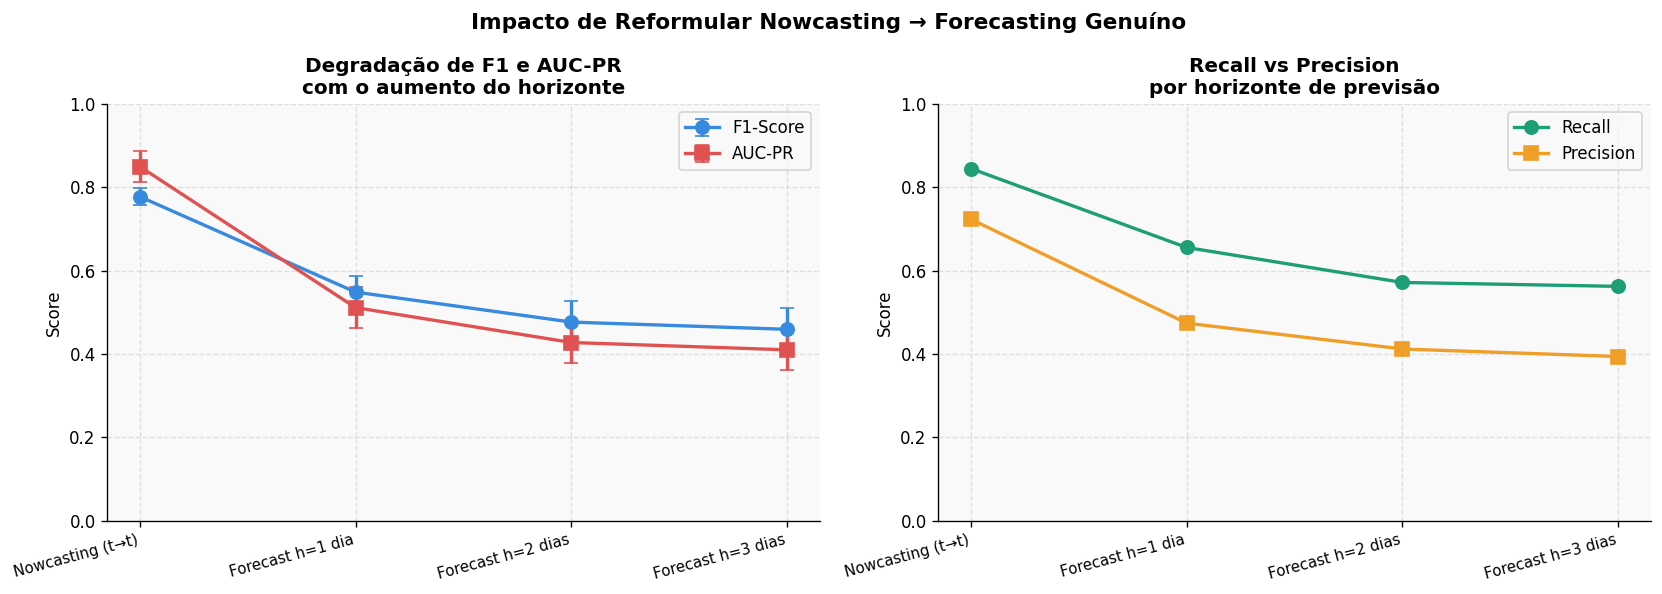


Queda ao sair de Nowcasting para Forecast h=1:
  ΔF1     = -0.229
  ΔAUC-PR = -0.339


In [21]:
# ── Visualização da queda de desempenho ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = list(results_horizon.keys())
x = range(len(labels))

# 4.1 AUC-PR e F1 por cenário
ax = axes[0]
f1_means  = [results_horizon[l]["test_f1"].mean() for l in labels]
f1_stds   = [results_horizon[l]["test_f1"].std()  for l in labels]
pr_means  = [results_horizon[l]["test_average_precision"].mean() for l in labels]
pr_stds   = [results_horizon[l]["test_average_precision"].std()  for l in labels]

ax.errorbar(x, f1_means, yerr=f1_stds, marker="o", color=BLUE, linewidth=2,
            markersize=8, capsize=4, label="F1-Score")
ax.errorbar(x, pr_means, yerr=pr_stds, marker="s", color=RED, linewidth=2,
            markersize=8, capsize=4, label="AUC-PR")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Degradação de F1 e AUC-PR\ncom o aumento do horizonte", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1)

# 4.2 Recall e Precision por cenário
ax = axes[1]
rec_means = [results_horizon[l]["test_recall"].mean() for l in labels]
prec_means = [results_horizon[l]["test_precision"].mean() for l in labels]
ax.plot(x, rec_means, marker="o", color=GREEN, linewidth=2, markersize=8, label="Recall")
ax.plot(x, prec_means, marker="s", color=ORANGE, linewidth=2, markersize=8, label="Precision")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Recall vs Precision\npor horizonte de previsão", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1)

plt.suptitle("Impacto de Reformular Nowcasting → Forecasting Genuíno", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Quantificar a queda
drop_f1 = f1_means[0] - f1_means[1]
drop_pr = pr_means[0] - pr_means[1]
print(f"\nQueda ao sair de Nowcasting para Forecast h=1:")
print(f"  ΔF1     = {-drop_f1:+.3f}")
print(f"  ΔAUC-PR = {-drop_pr:+.3f}")


## 5. Análise Detalhada — Forecast h=1 dia (cenário mais realista e aplicável)

O horizonte de 1 dia é o mais relevante para um sistema de alerta operacional: tempo
suficiente para mobilização (Defesa Civil, COE, sinalização), mas ainda próximo o bastante
para manter sinal preditivo aproveitável.


In [22]:
df_h1 = df[ALL_FEATURES + ["target_h1", "date"]].dropna().reset_index(drop=True)
X_h1 = df_h1[ALL_FEATURES]
y_h1 = df_h1["target_h1"]
dates_h1 = df_h1["date"]

splits = list(tscv.split(X_h1))
train_idx, test_idx = splits[-1]

model_h1 = make_rf(y_h1)
model_h1.fit(X_h1.iloc[train_idx], y_h1.iloc[train_idx])

y_pred = model_h1.predict(X_h1.iloc[test_idx])
y_prob = model_h1.predict_proba(X_h1.iloc[test_idx])[:,1]
y_test = y_h1.iloc[test_idx]
dates_test = dates_h1.iloc[test_idx]

print(f"Período de teste: {dates_test.min().date()} → {dates_test.max().date()}")
print(f"Amostras: {len(y_test):,}  |  Positivos: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print()
print(classification_report(y_test, y_pred, target_names=["Sem alag. (t+1)","Com alag. (t+1)"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR : {average_precision_score(y_test, y_prob):.4f}")


Período de teste: 2024-07-06 → 2026-05-28
Amostras: 692  |  Positivos: 135.0 (19.5%)

                 precision    recall  f1-score   support

Sem alag. (t+1)       0.91      0.77      0.83       557
Com alag. (t+1)       0.42      0.68      0.52       135

       accuracy                           0.75       692
      macro avg       0.66      0.72      0.67       692
   weighted avg       0.81      0.75      0.77       692

AUC-ROC: 0.8037
AUC-PR : 0.4760


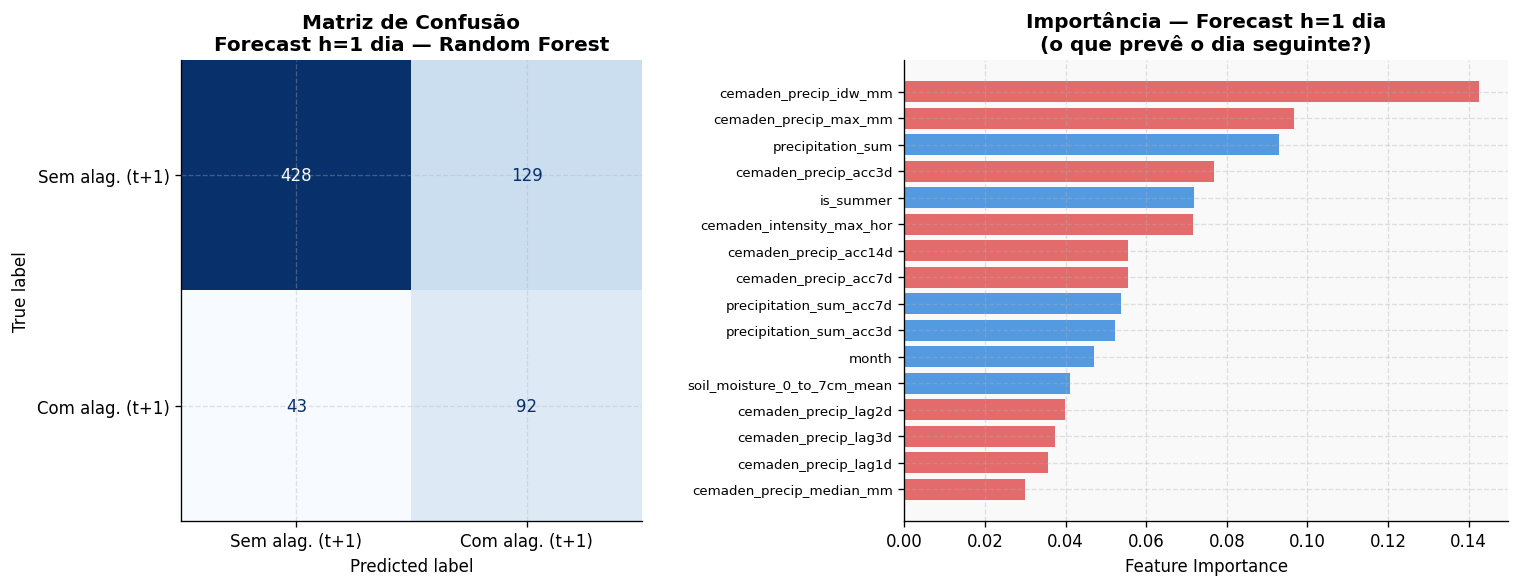


Top 8 features para prever alagamento em t+1:
cemaden_precip_idw_mm        0.142674
cemaden_precip_max_mm        0.096756
precipitation_sum            0.093071
cemaden_precip_acc3d         0.076729
is_summer                    0.071746
cemaden_intensity_max_hor    0.071606
cemaden_precip_acc14d        0.055414
cemaden_precip_acc7d         0.055379


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Sem alag. (t+1)", "Com alag. (t+1)"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de Confusão\nForecast h=1 dia — Random Forest", fontweight="bold")

# Feature importance
imp = pd.Series(model_h1.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)
colors_imp = [RED if f.startswith("cemaden") else BLUE for f in imp.index]
axes[1].barh(range(len(imp)), imp.values, color=colors_imp, alpha=0.85)
axes[1].set_yticks(range(len(imp)))
axes[1].set_yticklabels(imp.index, fontsize=8)
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Importância — Forecast h=1 dia\n(o que prevê o dia seguinte?)", fontweight="bold")

plt.tight_layout()
plt.show()

print("\nTop 8 features para prever alagamento em t+1:")
print(imp.sort_values(ascending=False).head(8).to_string())


## 6. Threshold Tuning — Forecast h=1

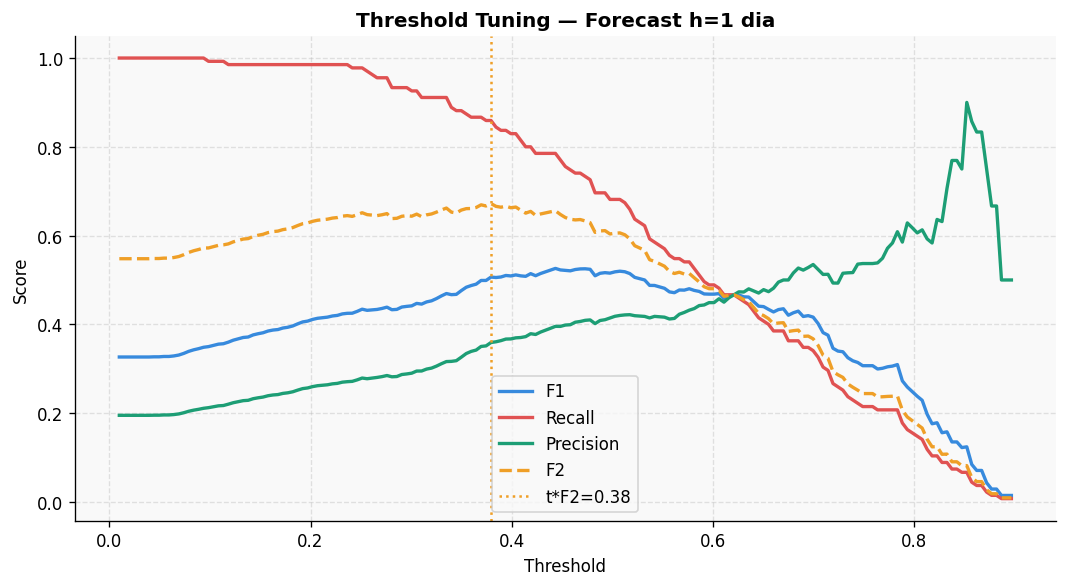

[t=0.44 | F1 ótimo]  F1=0.526  Recall=0.785  Precision=0.396
[t=0.38 | F2 ótimo]  F1=0.507  Recall=0.859  Precision=0.359
[t=0.50 | Default]  F1=0.517  Recall=0.681  Precision=0.416


In [24]:
thresholds = np.linspace(0.01, 0.99, 200)
metrics_thresh = []
for t in thresholds:
    yp = (y_prob >= t).astype(int)
    if yp.sum() == 0:
        continue
    p = precision_score(y_test, yp, zero_division=0)
    r = recall_score(y_test, yp, zero_division=0)
    f2 = (5*p*r)/(4*p+r+1e-9)
    metrics_thresh.append({"threshold": t, "f1": f1_score(y_test, yp, zero_division=0),
                           "recall": r, "precision": p, "f2": f2})
thresh_df = pd.DataFrame(metrics_thresh)

t_f1 = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]
t_f2 = thresh_df.loc[thresh_df["f2"].idxmax(), "threshold"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df["threshold"], thresh_df["f1"], color=BLUE, linewidth=2, label="F1")
ax.plot(thresh_df["threshold"], thresh_df["recall"], color=RED, linewidth=2, label="Recall")
ax.plot(thresh_df["threshold"], thresh_df["precision"], color=GREEN, linewidth=2, label="Precision")
ax.plot(thresh_df["threshold"], thresh_df["f2"], color=ORANGE, linewidth=2, linestyle="--", label="F2")
ax.axvline(t_f2, color=ORANGE, linestyle=":", linewidth=1.5, label=f"t*F2={t_f2:.2f}")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("Threshold Tuning — Forecast h=1 dia", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

for name, t in [("F1 ótimo", t_f1), ("F2 ótimo", t_f2), ("Default", 0.5)]:
    yp = (y_prob >= t).astype(int)
    print(f"[t={t:.2f} | {name}]  F1={f1_score(y_test,yp,zero_division=0):.3f}  "
          f"Recall={recall_score(y_test,yp,zero_division=0):.3f}  "
          f"Precision={precision_score(y_test,yp,zero_division=0):.3f}")


## 7. Conclusões — Nowcasting vs Forecasting

### Síntese

| Cenário | O que pergunta | Aplicação prática |
|---|---|---|
| Nowcasting (v1) | "Choveu hoje, alagou hoje?" | Monitoramento/diagnóstico em tempo real |
| Forecast h=1 | "Com o que sei hoje, vai alagar amanhã?" | Alerta com 24h de antecedência |
| Forecast h=2/h=3 | Idem, com mais antecedência | Planejamento de médio prazo |

### O que esperamos observar

1. **Queda de desempenho é esperada e correta** ao sair de nowcasting para forecast h=1 —
   isso reflete a natureza física do fenômeno (resposta rápida à chuva), não um erro de
   modelagem.
2. **A composição da importância de features deve mudar**: no nowcasting, a chuva do
   próprio dia domina; no forecast h=1, espera-se que acumulados (`acc3d`, `acc7d`) e
   indicadores de saturação do solo ganhem peso relativo, pois carregam informação de
   persistência que sobrevive ao deslocamento temporal.
3. **O horizonte h=1 é o mais defensável** como "previsão" no sentido estrito do termo,
   sendo o ponto de partida recomendado para qualquer aplicação de alerta real.

### Implicação para o TCC

Esta comparação deve ser apresentada como um resultado em si — não como uma falha a ser
escondida. Mostrar explicitamente a diferença entre nowcasting e forecasting genuíno, com
os números de degradação, fortalece o rigor metodológico do trabalho e antecipa uma
pergunta natural da banca.

### Próximos passos

- [ ] Avaliar se features de tendência (ex: derivada da precipitação nos últimos 3 dias)
      ajudam a recuperar parte do desempenho perdido no forecast
- [ ] Testar horizontes intermediários (12h, 18h) se houver granularidade horária disponível
- [ ] Avaliar combinação de horizontes (ensemble h=1+h=2+h=3) para um "índice de risco"
      contínuo em vez de classificação binária por dia fixo
